In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
from constants import *
import IPython.display as ipd
import matplotlib.pyplot as plt
from utils import stitch_wave_chunks
from dataset import train_data_loader, test_data_loader

In [12]:
x, y, fp_x, fp_y = next(iter(test_data_loader))
print(torch.min(x), torch.max(x))
print("Original shape:", x.shape)
# encoder
print("Encoder:")
x = nn.Conv1d(1, 16, 3, stride=2)(x)
print("1", x.shape)
x = nn.Conv1d(16, 32, 3, stride=2)(x)
print("2", x.shape)
x = nn.BatchNorm1d(32)(x)
print("2.1", x.shape)
x = nn.Conv1d(32, 64, 3, stride=2)(x)
print("3", x.shape)
x = nn.Conv1d(64, 128, 3, stride=2)(x)
print("4", x.shape)
x = nn.BatchNorm1d(128)(x)
print("4.1", x.shape)
# decoder
print("Decoder:")
x = nn.ConvTranspose1d(128, 64, 3, stride=1)(x)
print("5", x.shape)
x = nn.ConvTranspose1d(64, 32, 3, stride=1)(x)
print("6", x.shape)
x = nn.ConvTranspose1d(32, 16, 3, stride=1)(x)
print("7", x.shape)
x = nn.ConvTranspose1d(16, 1, 3, stride=1)(x)
print("8", x.shape)
x = nn.Linear(607, WINDOW_SAMPLE_LEN // 4)(x)
print("9", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 2)(x)
print("10", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN)(x)
print("11", x.shape)

tensor(0.1900) tensor(0.8629)
Original shape: torch.Size([8, 1, 9600])
Encoder:
1 torch.Size([8, 16, 4799])
2 torch.Size([8, 32, 2399])
2.1 torch.Size([8, 32, 2399])
3 torch.Size([8, 64, 1199])
4 torch.Size([8, 128, 599])
4.1 torch.Size([8, 128, 599])
Decoder:
5 torch.Size([8, 64, 601])
6 torch.Size([8, 32, 603])
7 torch.Size([8, 16, 605])
8 torch.Size([8, 1, 607])
9 torch.Size([8, 1, 2400])
10 torch.Size([8, 1, 4800])
11 torch.Size([8, 1, 9600])


In [66]:
class Gtr_2_Ney_AutoEncoder_Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=2),
            nn.LeakyReLU(),
            nn.Conv1d(16, 32, 3, stride=2),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.Conv1d(32, 64, 3, stride=2),
            nn.Sigmoid(),
            nn.Conv1d(64, 128, 3, stride=2),
            nn.BatchNorm1d(128)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(64, 32, 3, stride=1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(32, 16, 3, stride=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(16, 1, 3, stride=1),
            nn.BatchNorm1d(1),
            nn.LeakyReLU(),
            nn.Linear(607, WINDOW_SAMPLE_LEN // 4),
            nn.Sigmoid(),
            nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [67]:
# Epoch: 90	Loss: 0.005935
gtr_2_ney_model_conv = Gtr_2_Ney_AutoEncoder_Conv()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model_conv.parameters(), lr=0.001)

for epoch in range(120):
    running_loss = 0.0
    for gtr_features, ney_features, _, _ in train_data_loader:
        y_hat = gtr_2_ney_model_conv(gtr_features)
        loss = criterion(y_hat, ney_features)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch: {epoch + 1:03d}\tLoss: {running_loss:.6f}")

Epoch: 01	Loss: 1.206564
Epoch: 02	Loss: 0.956204
Epoch: 03	Loss: 0.948783
Epoch: 04	Loss: 0.927282
Epoch: 05	Loss: 0.923386
Epoch: 06	Loss: 0.915547
Epoch: 07	Loss: 0.920882
Epoch: 08	Loss: 0.921720
Epoch: 09	Loss: 0.913572
Epoch: 10	Loss: 0.917311
Epoch: 11	Loss: 0.917269
Epoch: 12	Loss: 0.915246
Epoch: 13	Loss: 0.921134
Epoch: 14	Loss: 0.918736
Epoch: 15	Loss: 0.916092
Epoch: 16	Loss: 0.918440
Epoch: 17	Loss: 0.918543
Epoch: 18	Loss: 0.908735
Epoch: 19	Loss: 0.892481
Epoch: 20	Loss: 0.890905
Epoch: 21	Loss: 0.877780
Epoch: 22	Loss: 0.857741
Epoch: 23	Loss: 0.844520
Epoch: 24	Loss: 0.815306
Epoch: 25	Loss: 0.795607
Epoch: 26	Loss: 0.768157
Epoch: 27	Loss: 0.732343
Epoch: 28	Loss: 0.699339
Epoch: 29	Loss: 0.679232
Epoch: 30	Loss: 0.633920
Epoch: 31	Loss: 0.597768
Epoch: 32	Loss: 0.555119
Epoch: 33	Loss: 0.523833
Epoch: 34	Loss: 0.540677
Epoch: 35	Loss: 0.485977
Epoch: 36	Loss: 0.439484
Epoch: 37	Loss: 0.392714
Epoch: 38	Loss: 0.354123
Epoch: 39	Loss: 0.326612
Epoch: 40	Loss: 0.298790


In [68]:
x, y, x_paths, y_paths = next(iter(test_data_loader))
print(x_paths)
print(y_paths)
predicted_chunks = None
with torch.no_grad():
    predicted_chunks = gtr_2_ney_model_conv(x).numpy()
    print(predicted_chunks.shape)
predicted_chunks = (np.squeeze(predicted_chunks, axis=1) * 2) - 1
target_chunks = (np.squeeze(y.numpy(), axis=1) * 2) - 1

stitched_wave_prediction = stitch_wave_chunks(predicted_chunks)
print("Prediction length:", len(stitched_wave_prediction))
stitched_wave_target = stitch_wave_chunks(target_chunks)
print("Target length:", len(stitched_wave_target))

('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_4', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_5', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_6', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_7')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3', 'dataset/features/ney/08_Ney_G_S_3/chunk_4', 'dataset/features/ney/08_Ney_G_S_3/chunk_5', 'dataset/features/ney/08_Ney_G_S_3/chunk_6', 'dataset/features/ney/08_Ney_G_S_3/chunk_7')
(8, 1, 9600)
Prediction length: 76100
Target length: 76100


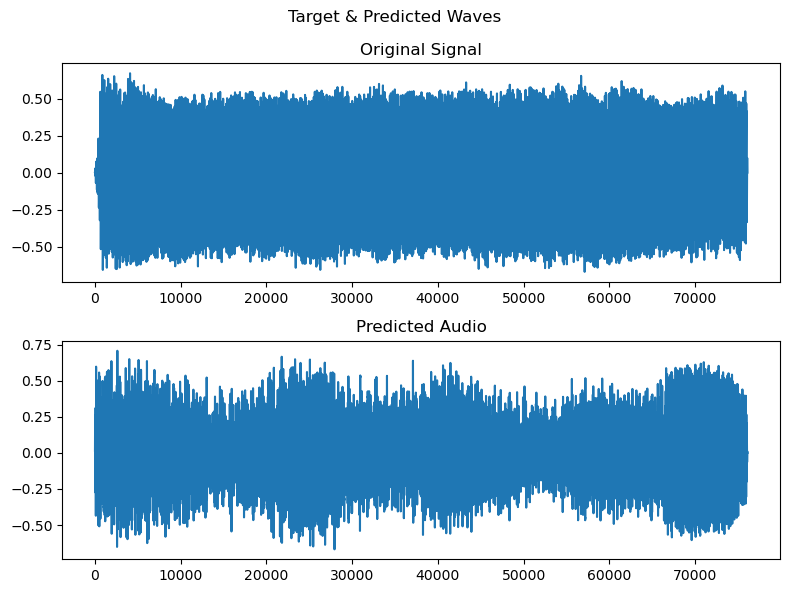

In [69]:
fig, axs = plt.subplots(2, figsize=(8, 6))
fig.suptitle("Target & Predicted Waves")
axs[0].set_title("Original Signal")
axs[0].plot(stitched_wave_target)
axs[1].set_title("Predicted Audio")
axs[1].plot(stitched_wave_prediction)
fig.tight_layout()
plt.show()

In [70]:
ipd.Audio(stitched_wave_target, rate=SR)

In [71]:
ipd.Audio(stitched_wave_prediction, rate=SR)